In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
import geopandas as gpd
import sys
import pickle
import json

sys.path.insert(0, "../../../utils")

from modules import *

import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

REGION = 'Nord'

ΤARGET = "_und5"  # "_und5", "_ovr5", "_prgn", "_severe", "_hospitalization" or ""

In [2]:
target_variable = {"": "Total Malaria Cases",
                   "_und5": "Malaria Cases Under 5 Years",
                   "_ovr5": "Malaria Cases Over 5 Years",
                   "_prgn": "Malaria Cases in Pregnant Women",
                   "_severe": "Total Severe Malaria Cases",
                   "_hospitalization": "Total Malaria Hospitalizations"}

In [3]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Test_Dataset_2015-2025.csv', encoding=enc)

In [4]:
dataframe

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015-01,2015,1,0.5,...,33.33,26.33,1968.0,537.0,0.0,114.71,1294.0,1.0,240.0,1294.0
1,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015-01,2015,1,0.5,...,34.33,25.67,2013.0,583.0,0.0,120.04,1353.0,2.0,94.0,1275.0
2,nord,benoue,bibemi,bide,13.972945,9.422292,2015-01,2015,1,0.5,...,34.50,26.83,1845.0,540.0,0.0,120.79,1240.0,0.0,81.0,1178.0
3,nord,benoue,bibemi,dengui,13.642496,9.235656,2015-01,2015,1,0.5,...,33.67,25.83,2049.0,539.0,0.0,112.59,1314.0,1.0,243.0,1314.0
4,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015-01,2015,1,0.5,...,34.00,28.00,1872.0,521.0,0.0,119.39,1228.0,0.0,98.0,997.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19075,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2025-12,2025,12,0.0,...,29.83,22.83,2887.0,796.0,0.0,111.36,1749.0,0.0,288.0,1749.0
19076,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2025-12,2025,12,0.0,...,31.17,23.67,2647.0,795.0,0.0,118.21,1678.0,0.0,114.0,1678.0
19077,nord,mayo-rey,touboro,touboro,15.293957,7.759324,2025-12,2025,12,0.0,...,32.17,23.83,2850.0,833.0,0.0,116.11,1796.0,0.0,249.0,1780.0
19078,nord,mayo-rey,touboro,vogzom,14.714359,7.747549,2025-12,2025,12,0.0,...,31.00,23.00,2877.0,766.0,0.0,109.01,1708.0,0.0,305.0,432.0


In [5]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location_full'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location', 'location_full'] + dataframe.columns.to_list()[:-2]]

In [6]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [7]:
inference = dataframe[dataframe["dt_prediction"] > pd.Period("2024-09", freq="M")]
inference.reset_index(drop=True, inplace=True)

inference.head()

,location,location_full,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"(nord, bibemi, adoumri)","(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2024-10,-0.866,0.5,0.582223,0.172216,-0.460121,...,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,"(nord, bibemi, bibemi)","(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2024-10,-0.866,0.5,0.545215,0.114901,-0.444923,...,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,"(nord, bibemi, bide)","(nord, benoue, bibemi, bide)",13.972945,9.422292,2024-10,-0.866,0.5,0.543668,0.149829,-0.390567,...,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,"(nord, bibemi, dengui)","(nord, benoue, bibemi, dengui)",13.642496,9.235656,2024-10,-0.866,0.5,0.455755,0.184400,-0.343349,...,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,"(nord, bibemi, djaloumi)","(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2024-10,-0.866,0.5,0.526682,0.117692,-0.448780,...,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [8]:
with open(f'saved/CM_{REGION}_bin_ranges{ΤARGET}.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 8


In [9]:
with open(f"saved/CM_{REGION}_rfecv_model{ΤARGET}.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

with open(f"saved/CM_{REGION}_scaler{ΤARGET}.pkl", "rb") as f:
    fitted_scaler = pickle.load(f)

with open(f"saved/CM_{REGION}_imputer{ΤARGET}.pkl", "rb") as f:
    fitted_imputer = pickle.load(f)

with open(f"saved/CM_{REGION}_xgb_model{ΤARGET}.pkl", "rb") as f:
    fitted_model = pickle.load(f)

In [10]:
X_test = inference.select_dtypes(exclude=['object', 'period[M]'])
X_test.head()

,x,y,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,13.770202,9.240232,-0.866,0.5,0.582223,0.172216,-0.460121,-0.172216,0.566326,0.157181,...,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,13.949181,9.263633,-0.866,0.5,0.545215,0.114901,-0.444923,-0.114901,0.540234,0.114280,...,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,13.972945,9.422292,-0.866,0.5,0.543668,0.149829,-0.390567,-0.149829,0.538927,0.146131,...,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,13.642496,9.235656,-0.866,0.5,0.455755,0.184400,-0.343349,-0.184400,0.460733,0.172288,...,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,13.994667,9.585190,-0.866,0.5,0.526682,0.117692,-0.448780,-0.117692,0.475079,0.161327,...,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [11]:
X_test_scaled = pd.DataFrame(fitted_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [12]:
X_test_imputed = pd.DataFrame(fitted_imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [13]:
X_test_imputed = pd.DataFrame(fitted_scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [14]:
X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X_test.columns[fitted_rfe.support_], index=X_test.index)

In [15]:
y_test_pred = fitted_model.predict(X_test_rfe)

In [16]:
y_test_pred = np.clip(np.round(y_test_pred), 0, num_of_classes -1).astype(int)

In [17]:
y_test_pred

array([4, 5, 3, ..., 4, 5, 4])

In [18]:
results_test = pd.DataFrame({'prediction': y_test_pred})

results_test['dt_prediction'] = inference.loc[results_test.index, 'dt_prediction']
results_test['dt_reference'] = results_test['dt_prediction']+3

results_test.reset_index(drop=True, inplace=True)

In [20]:
results_test

,prediction,dt_prediction,dt_reference
0,4,2024-10,2025-01
1,5,2024-10,2025-01
2,3,2024-10,2025-01
3,4,2024-10,2025-01
4,3,2024-10,2025-01
...,...,...,...
2170,3,2025-12,2026-03
2171,3,2025-12,2026-03
2172,4,2025-12,2026-03
2173,5,2025-12,2026-03


In [21]:
results_df = pd.merge(inference[['location', 'location_full', 'x', 'y']], results_test, left_index=True, right_index=True, how='inner')
results_df['classes_range'] = num_of_classes-1
results_df['target'] = target_variable[ΤARGET]

In [22]:
polygon_ids = pd.read_csv(f'../../../data/CM_WEB_Polygons_processed.csv', encoding=enc)

polygon_ids['location'] = polygon_ids['location'].astype(str)
results_df['location'] = results_df['location'].astype(str)

In [23]:
results_df = pd.merge(results_df, polygon_ids, on=['location'], how='left')
results_df.drop(columns=['location'], inplace=True)
results_df.rename(columns={'location_full': 'location', 'id': 'polygon_id'}, inplace=True)
results_df = results_df[['location', 'polygon_id', 'x', 'y', 'target', 'classes_range', 'dt_prediction', 'dt_reference', 'prediction']]

In [24]:
results_df = results_df[['location', 'polygon_id', 'x', 'y', 'target', 'classes_range', 'dt_prediction', 'dt_reference', 'prediction']]

In [25]:
results_df

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction
0,"(nord, benoue, bibemi, adoumri)",73,13.770202,9.240232,Malaria Cases Under 5 Years,7,2024-10,2025-01,4
1,"(nord, benoue, bibemi, bibemi)",71,13.949181,9.263633,Malaria Cases Under 5 Years,7,2024-10,2025-01,5
2,"(nord, benoue, bibemi, bide)",67,13.972945,9.422292,Malaria Cases Under 5 Years,7,2024-10,2025-01,3
3,"(nord, benoue, bibemi, dengui)",76,13.642496,9.235656,Malaria Cases Under 5 Years,7,2024-10,2025-01,4
4,"(nord, benoue, bibemi, djaloumi)",68,13.994667,9.585190,Malaria Cases Under 5 Years,7,2024-10,2025-01,3
...,...,...,...,...,...,...,...,...,...
2170,"(nord, mayo-rey, touboro, mbeing)",127,15.001895,7.650008,Malaria Cases Under 5 Years,7,2025-12,2026-03,3
2171,"(nord, mayo-rey, touboro, ngai-lara)",59,15.110765,7.963850,Malaria Cases Under 5 Years,7,2025-12,2026-03,3
2172,"(nord, mayo-rey, touboro, touboro)",57,15.293957,7.759324,Malaria Cases Under 5 Years,7,2025-12,2026-03,4
2173,"(nord, mayo-rey, touboro, vogzom)",62,14.714359,7.747549,Malaria Cases Under 5 Years,7,2025-12,2026-03,5


<Axes: title={'center': 'Predicted Case Bin Distribution'}, xlabel='Bins', ylabel='Frequency'>

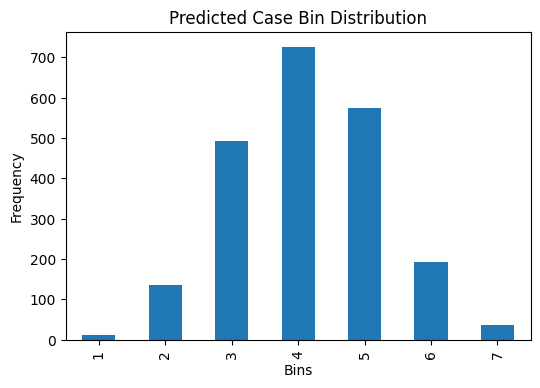

In [26]:
results_df.prediction.value_counts().sort_index().plot(kind='bar', 
                                                              figsize=(6, 4), 
                                                              title='Predicted Case Bin Distribution', 
                                                              xlabel='Bins', 
                                                              ylabel='Frequency')

In [41]:
period = "2026-03"

test_results_to_send = results_df[results_df["dt_reference"] == pd.Period(period, freq="M")]
test_results_to_send.to_csv(f'../../../data/{REGION}/results/CM_{REGION}_Inference_{period}{ΤARGET}.csv', index=False, encoding=enc)

<Axes: title={'center': 'Predicted Case Bin Distribution'}, xlabel='Bins', ylabel='Frequency'>

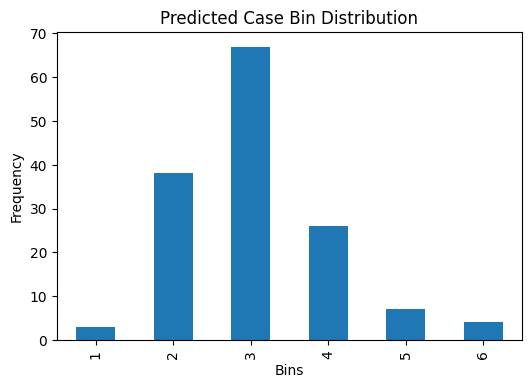

In [42]:
test_results_to_send.prediction.value_counts().sort_index().plot(kind='bar', 
                                                              figsize=(6, 4), 
                                                              title='Predicted Case Bin Distribution', 
                                                              xlabel='Bins', 
                                                              ylabel='Frequency')

In [43]:
shapefile_path = "../../../../../../Shapefiles/Cameroon Shapefiles/new/"
shapefile = gpd.read_file(f"{shapefile_path}web_platform/CM_Nord_LV3.shp",  encoding=enc)

shapefile['location'] = list(zip(shapefile['GID0'],shapefile['GID1'], shapefile['GID2'], shapefile['GID3']))

In [44]:
results_shapefile = gpd.GeoDataFrame(pd.merge(test_results_to_send, shapefile[['location', 'geometry']], on='location', how='left'), 
                                            geometry='geometry',
                                            crs=shapefile.crs)

results_shapefile.drop(columns=['location'], inplace=True)
results_shapefile['dt_prediction'] = results_shapefile['dt_prediction'].astype(str)
results_shapefile['dt_reference'] = results_shapefile['dt_reference'].astype(str)

In [45]:
results_shapefile.head(3)

,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,geometry
0,73,13.770202,9.240232,Malaria Cases Under 5 Years,7,2025-12,2026-03,3,"POLYGON ((13.79028 9.30949, 13.79040 9.30947, ..."
1,71,13.949181,9.263633,Malaria Cases Under 5 Years,7,2025-12,2026-03,4,"POLYGON ((13.90046 9.39271, 13.90212 9.39081, ..."
2,67,13.972945,9.422292,Malaria Cases Under 5 Years,7,2025-12,2026-03,2,"POLYGON ((13.97150 9.52624, 13.97152 9.52621, ..."


In [46]:
results_shapefile.to_file(f'../../../data/{REGION}/results/CM_{REGION}_Inference_TEST{ΤARGET}.shp', index=False, encoding=enc)

C:\Users\dimit\AppData\Local\Temp\ipykernel_10220\12272870.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  results_shapefile.to_file(f'../../../data/{REGION}/results/CM_{REGION}_Inference_TEST{ΤARGET}.shp', index=False, encoding=enc)


Text(0.5, 1.0, 'Malaria Cases Under 5 Years Prediction\nRegion: Cameroon North\nDate of prediction: 2025-12\nDate of reference: 2026-03')

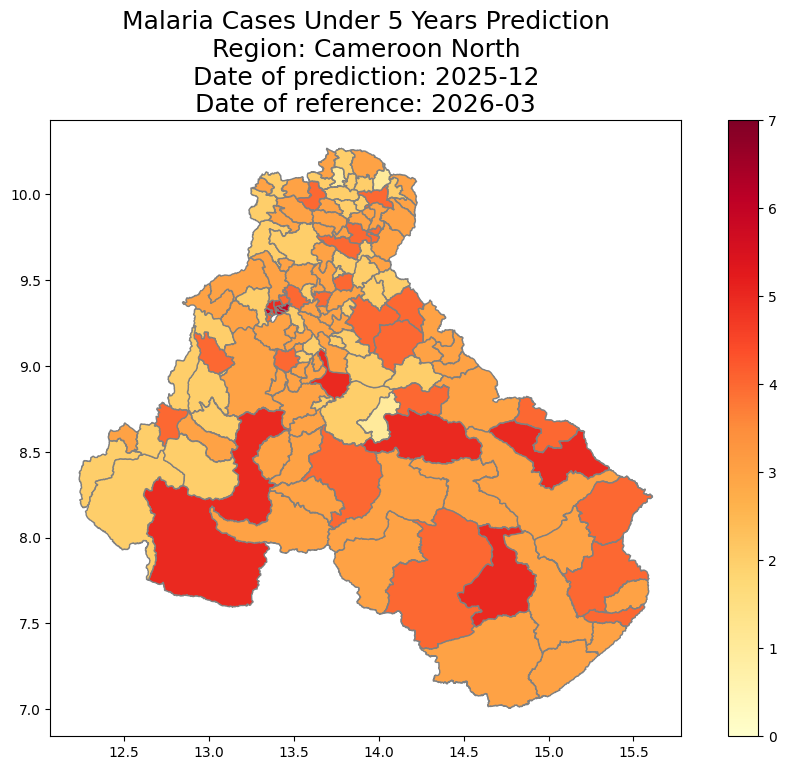

In [47]:
float_column = 'prediction'
cmap = plt.cm.YlOrRd
figure_size = (12,8)
title_size = 18

fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_shapefile.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = results_shapefile.classes_range.iloc[1])
plt.title(f'{target_variable[ΤARGET]} Prediction\nRegion: Cameroon North\nDate of prediction: {results_shapefile.dt_prediction.iloc[1]}\nDate of reference: {results_shapefile.dt_reference.iloc[1]}', 
          size = title_size)
# plt.show()